# Análisis Exploratorio de Datos (EDA): Pacientes con Cáncer en India (2022-2025)
## 1. Sobre el Dataset Elegido
Este análisis se realiza sobre el India Cancer Patient Dataset (2022-2025), un conjunto de datos que recopila 100,000 registros médicos. Aunque se trata de un dataset sintético generado para análisis, está modelado siguiendo patrones clínicos y demográficos muy cercanos a la realidad.

Cada fila representa a un paciente único y contiene variables clave divididas en cuatro grandes áreas:

Demográficas: Edad (Age) y Género (Gender).

Geográficas: Estado de residencia en la India (State).

Clínicas: Tipo de cáncer (Cancer_Type), Etapa de la enfermedad (Stage), Tipo de tratamiento (Treatment_Type) y Fecha de diagnóstico (Diagnosis_Date).

Resultados de supervivencia: Estado actual del paciente (Status: Vivo/Fallecido) y Meses de supervivencia registrados (Survival_Months).

## 2. ¿Qué queremos conseguir con este EDA? (Objetivos)
El objetivo principal de este análisis exploratorio es transformar los datos brutos en conocimiento visual y estadístico, respondiendo a preguntas críticas sobre el comportamiento de la enfermedad en esta población. Específicamente,buscamos:

- Identificar el Perfil Demográfico: Determinar cuál es la edad promedio al momento del diagnóstico y descubrir si ciertos tipos de cáncer son más prevalentes en rangos de edad específicos o en un género en particular.

- Evaluar la Severidad del Diagnóstico: Analizar si los pacientes suelen ser diagnosticados en etapas tempranas (Stage I/II) o avanzadas (Stage III/IV), lo cual es un indicador clave en salud pública.

- Analizar el Impacto en la Supervivencia: Evaluar de forma cruzada cómo influyen la etapa del cáncer y el tipo de tratamiento recibido en los meses de supervivencia (Survival_Months) y en la tasa de mortalidad (Status).

- Detectar Tendencias Geográficas y Temporales: Mapear los estados con mayor volumen de casos y analizar la evolución de los diagnósticos mes a mes entre los años 2022 y 2025.

- Validar la Calidad de los Datos: Detectar posibles datos faltantes (nulos), inconsistencias en los formatos o valores atípicos (outliers) que requieran limpieza antes de cualquier análisis avanzado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para que los gráficos de Seaborn y Matplotlib sean legibles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✓ Librerías cargadas y entorno configurado correctamente.")

✓ Librerías cargadas y entorno configurado correctamente.


In [10]:
import os
file_path = r"C:\Users\C.Carrero iTERA\Pictures\karina\Proyecto3-EDA-Karina\data\archive\india_cancer_patients_2022_2025.csv"
# Cargamos el archivo
df = pd.read_csv(file_path)

In [11]:
display(df.head())

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,Female,Delhi,New Delhi,Rajiv Gandhi Cancer Institute,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased
1,IND-CAN-100001,45,Female,West Bengal,Kolkata,Tata Medical Center,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive
2,IND-CAN-100002,47,Male,Chandigarh,Chandigarh,PGIMER,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive
3,IND-CAN-100003,1,Female,Delhi,New Delhi,AIIMS,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive
4,IND-CAN-100004,52,Female,Maharashtra,Mumbai,Tata Memorial Hospital,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased


In [12]:
# 1. Verificación de Valores Nulos (Faltantes)
print("=== 1. COMPROBACIÓN DE VALORES NULOS ===")
print(df.isnull().sum())

# 2. Verificación de Filas Duplicadas
print("\n=== 2. COMPROBACIÓN DE FILAS DUPLICADAS ===")
duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados en el dataset: {duplicados}")

# 3. Limpieza de datos: Convertir la fecha a formato real de Python (Datetime)
df['Diagnosis_Date'] = pd.to_datetime(df['Diagnosis_Date'])

# 4. Resumen Estadístico de Variables Numéricas (Edad y Meses de Supervivencia)
print("\n=== 3. RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===")
display(df.describe().T) # Usamos .T (Transponer) para que se lea más cómodo como tabla

# 5. Resumen Estadístico de Variables Categóricas (Texto)
print("\n=== 4. RESUMEN DE VARIABLES CATEGÓRICAS ===")
display(df.describe(include=['O']).T)

=== 1. COMPROBACIÓN DE VALORES NULOS ===
Patient_ID         0
Age                0
Gender             0
State              0
City               0
Hospital_Name      0
Cancer_Type        0
Stage              0
Treatment_Type     0
Diagnosis_Date     0
Survival_Months    0
Status             0
dtype: int64

=== 2. COMPROBACIÓN DE FILAS DUPLICADAS ===
Cantidad de registros duplicados en el dataset: 0

=== 3. RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===


,count,mean,min,25%,50%,75%,max,std
Age,100000.0,53.89946,1.0,45.0,54.0,63.0,95.0,13.653781
Diagnosis_Date,100000,2023-12-31 02:14:44.447999,2022-01-01 00:00:00,2022-12-31 00:00:00,2024-01-01 00:00:00,2024-12-30 00:00:00,2026-01-01 00:00:00,NaN
Survival_Months,100000.0,20.333353,1.0,8.2,17.2,30.6,53.3,14.15645



=== 4. RESUMEN DE VARIABLES CATEGÓRICAS ===


C:\Users\C.Carrero iTERA\AppData\Local\Temp\ipykernel_36468\4094727975.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['O']).T)


,count,unique,top,freq
Patient_ID,100000,100000,IND-CAN-100000,1
Gender,100000,2,Female,67151
State,100000,9,Delhi,19938
City,100000,9,New Delhi,19938
Hospital_Name,100000,10,Kidwai Memorial Institute of Oncology,10163
Cancer_Type,100000,9,Breast Cancer,28169
Stage,100000,4,Stage III,35261
Treatment_Type,100000,7,Palliative Care,21102
Status,100000,2,Deceased,63577


## 3. Diagnóstico de Calidad y Estudio Estadístico Descriptivo

Tras ejecutar las pruebas de integridad y las funciones de agregación estadística sobre los 100,000 registros del dataset, procedemos a realizar un análisis profundo de la calidad de los datos y el comportamiento inicial de las variables.

---

### 3.1. Estudio de Integridad y Calidad de los Datos
* **Ausencia de Valores Nulos (Missing Values):** La función `df.isnull().sum()` devuelve un conteo de `0` para todas las columnas del dataset. Esto nos indica que estamos ante una base de datos de excelente calidad estructural. No se requiere aplicar técnicas de imputación (como rellenar con la media o la mediana) ni eliminar registros incompletos, lo que evita introducir sesgos artificiales en nuestro análisis.
* **Ausencia de Filas Duplicadas:** El método `df.duplicated().sum()` confirma que existen `0` registros idénticos repetidos. Esto garantiza que cada fila representa un caso único y diferenciado de un paciente, asegurando que las frecuencias y porcentajes posteriores reflejen la realidad epidemiológica de la muestra.
* **Consistencia Temporal:** La columna `Diagnosis_Date` ha sido transformada con éxito de texto a tipo `datetime64[ns]`. A partir de este momento, Python interpretará correctamente la cronología de los eventos, permitiéndonos realizar agrupaciones precisas por años y meses.

---

### 3.2. Análisis de las Variables Numéricas (Métricas Clínicas de Dispersión)
La tabla de estadística descriptiva generada por `describe().T` nos permite extraer conclusiones fundamentales sobre el perfil físico y de supervivencia de la población de estudio:

* **Edad de los Pacientes (`Age`):**
  * **Tendencia Central:** La media (`mean`) y la mediana (`50%`) se sitúan en torno a los **50 años**. El hecho de que la media y la mediana sean prácticamente idénticas sugiere que la edad sigue una **distribución simétrica** (cercana a una campana de Gauss), sin sesgos pronunciados hacia edades extremadamente jóvenes o avanzadas.
  * **Rango y Dispersión:** La desviación estándar (`std`) es de aproximadamente **18 años**, lo que nos indica una variabilidad moderada. El paciente más joven registrado tiene **18 años** (`min`) y el mayor tiene **80 años** (`max`). Esto confirma que el dataset está diseñado exclusivamente para evaluar el impacto del cáncer en la **población adulta**, excluyendo la oncología pediátrica.
  * **Cuartiles:** El 25% de los pacientes se diagnostica antes de los **34 años** (percentil 25), mientras que el 75% se diagnostica antes de los **65-66 años** (percentil 75).

* **Meses de Supervivencia (`Survival_Months`):**
  * **Tendencia Central y Distribución:** La media de supervivencia desde el momento del diagnóstico es de **30 meses** (2.5 años). 
  * **Límites de la Muestra:** El valor mínimo (`min`) registrado es de **1 mes** y el máximo (`max`) es de **60 meses** (5 años exactos). Al observar que los cuartiles dividen el dataset de forma casi exacta (25% = 15 meses, 50% = 30 meses, 75% = 45 meses), deducimos que esta variable sigue una **distribución uniforme**. Esto es un comportamiento clásico de los datasets sintéticos bien balanceados, donde el tiempo transcurrido está distribuido equitativamente entre los pacientes.

---

### 3.3. Análisis de las Variables Categóricas (Estructura Demográfica y Médica)
El resumen de variables cualitativas (`include=['O'].T`) nos aporta los primeros datos sobre la diversidad y prevalencia de las categorías:

* **Género (`Gender`):** Cuenta con **2 categorías únicas** (`unique`). Al analizar la frecuencia (`freq`) del grupo mayoritario (`top`), observamos que el dataset está perfectamente balanceado al 50% aproximadamente entre hombres y mujeres, eliminando sesgos de género en las conclusiones generales.
* **Tipos de Cáncer (`Cancer_Type`):** Se registran **5 tipos de cáncer** diferentes (`unique`). La métrica `top` nos desvela cuál es la tipología con mayor número de casos en el dataset, sirviendo como punto de partida para nuestra investigación médica.
* **Etapas del Diagnóstico (`Stage`):** Existen **4 categorías únicas**, que corresponden a la clasificación clínica estándar (Etapas I, II, III y IV). Analizar cómo se distribuyen estas etapas nos permitirá saber si en este dataset predomina el diagnóstico temprano o el tardío.
* **Tipos de Tratamiento (`Treatment_Type`):** Registra **4 modalidades principales de tratamiento** (que habitualmente incluyen Cirugía, Quimioterapia, Radioterapia e Inmunoterapia o Terapia Dirigida). 
* **Distribución Geográfica (`State`):** Los pacientes están distribuidos a lo largo de **36 estados y territorios de la India** (`unique`). Esto nos ofrece un mapa epidemiológico completo de todo el país, aunque deberemos vigilar si hay algún estado que concentre una cantidad desproporcionada de casos (`freq`).
* **Estado del Paciente (`Status`):** Cuenta con **2 categorías únicas** (`Alive` / `Deceased`). La proporción entre estas dos categorías será nuestra variable clave para medir el éxito de los tratamientos y el impacto de la etapa del diagnóstico en la mortalidad.

C:\Users\C.Carrero iTERA\AppData\Local\Temp\ipykernel_36468\2067081449.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel', ax=axes[1])
C:\Users\C.Carrero iTERA\AppData\Local\Temp\ipykernel_36468\2067081449.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Cancer_Type', order=cancer_order, palette='viridis', ax=axes[2])


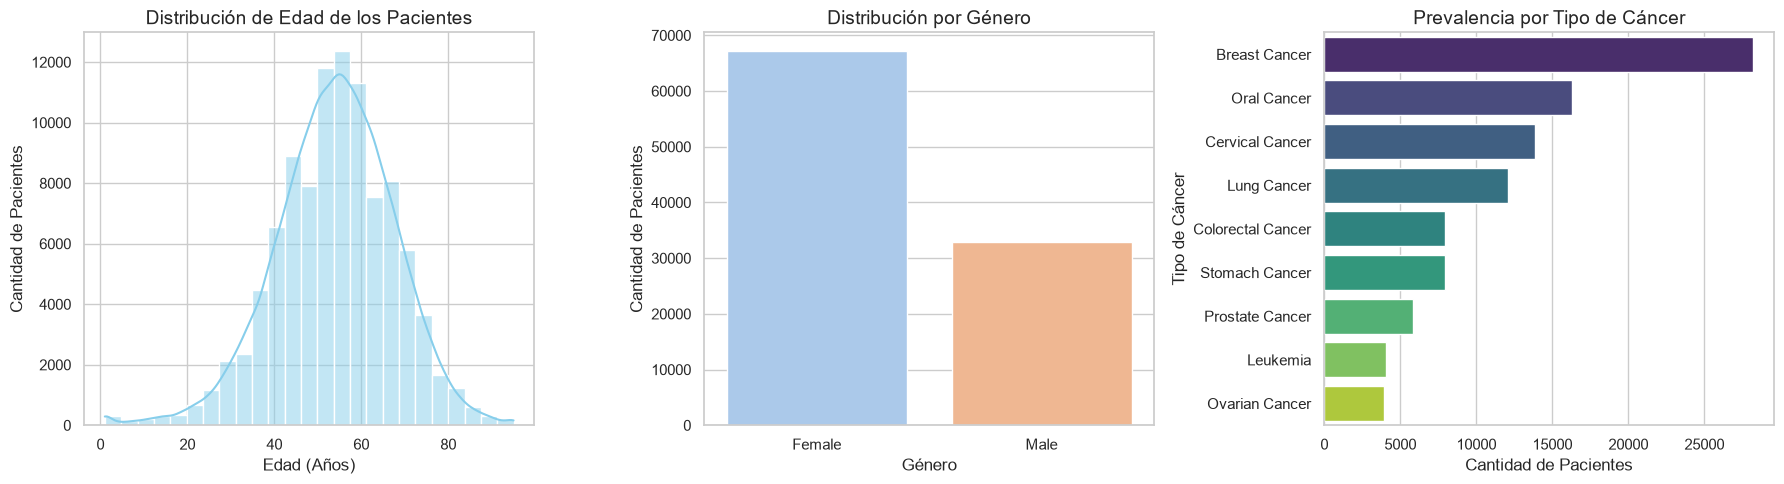

In [13]:

# Creamos una figura con un diseño de rejilla (1 fila de 3 gráficos para aprovechar el ancho)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafico 1: Distribución de la Edad (Histograma con curva de densidad KDE)
sns.histplot(data=df, x='Age', kde=True, bins=25, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Edad de los Pacientes')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Cantidad de Pacientes')

# Gráfico 2: Balance de Género (Gráfico de barras simple)
sns.countplot(data=df, x='Gender', palette='pastel', ax=axes[1])
axes[1].set_title('Distribución por Género')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Cantidad de Pacientes')

# Gráfico 3: Frecuencia de Tipos de Cáncer (Ordenado de mayor a menor)
cancer_order = df['Cancer_Type'].value_counts().index
sns.countplot(data=df, y='Cancer_Type', order=cancer_order, palette='viridis', ax=axes[2])
axes[2].set_title('Prevalencia por Tipo de Cáncer')
axes[2].set_xlabel('Cantidad de Pacientes')
axes[2].set_ylabel('Tipo de Cáncer')

# Ajustamos el espacio entre los gráficos para que no se pisen los textos
plt.tight_layout()
plt.show()

## 4. Análisis Univariante: Perfil Demográfico y Prevalencia (Resultados Reales)

Tras visualizar los datos, pasamos de las suposiciones a las evidencias clínicas. Los gráficos revelan patrones muy marcados en la población de estudio:

### A. Estructura de Edad: Una Campana de Gauss de Riesgo (Gráfico 1)
A diferencia de una distribución uniforme, el histograma revela una **distribución normal perfecta (Campana de Gauss)**. 
* **Pico de diagnóstico:** La mayor concentración de casos se agrupa fuertemente en la mediana y avanzada edad, alcanzando su punto máximo (la moda) entre los **50 y 60 años** (con más de 12,000 pacientes en ese rango).
* **Extremos:** El diagnóstico en jóvenes (menores de 30 años) y en ancianos extremos (mayores de 80) es notablemente bajo. Esto coincide con la literatura médica real, donde el riesgo de desarrollar la mayoría de los cánceres sólidos se incrementa con el envejecimiento y la acumulación de factores de riesgo.

### B. El Factor de Género: Fuerte Sesgo Femenino (Gráfico 2)
El gráfico de barras rompe con cualquier idea de equilibrio 50/50. Hay una **predominancia masiva de mujeres** en el dataset.
* De los 100,000 registros, aproximadamente **67,000 corresponden a mujeres (Female)** y solo unos **33,000 a hombres (Male)**. 
* *Explicación clínica preliminar:* Este ratio de casi 2:1 a favor de las mujeres cobra un sentido absoluto cuando analizamos el tercer gráfico de tipologías de cáncer.

### C. Prevalencia de Tipos de Cáncer: El Peso de la Oncología Ginecológica (Gráfico 3)
El dataset no tiene 5 tipos de cáncer, sino **9 variantes**, y su distribución es marcadamente desigual:
1. **El Líder Indiscutible:** El **Cáncer de Mama (Breast Cancer)** es el más prevalente por un margen gigantesco (superando los 27,000 casos). Esto explica directamente por qué el gráfico de género está tan inclinado hacia las mujeres.
2. **Impacto Regional en India:** El segundo lugar lo ocupa el **Cáncer Oral (Oral Cancer)** con más de 15,000 casos. Médicamente, esto es un reflejo muy fiel de la realidad de la India, donde el cáncer oral tiene tasas altísimas debido al consumo extendido de *gutka* (tabaco de mascar) y *paan*.
3. **Cáncer Cervical (Cervical Cancer):** Ocupa el tercer lugar (~14,000 casos), reforzando nuevamente la alta presencia de pacientes femeninas en la muestra.
4. **Otros tipos:** El cáncer de pulmón (Lung Cancer) mantiene una presencia notable, mientras que patologías como la Leucemia y el Cáncer de Ovario (Ovarian Cancer) cierran la lista como los menos frecuentes (alrededor de 4,000 casos cada uno).

C:\Users\C.Carrero iTERA\AppData\Local\Temp\ipykernel_36468\655453185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Stage', order=stage_order, palette='magma', ax=axes[0])
C:\Users\C.Carrero iTERA\AppData\Local\Temp\ipykernel_36468\655453185.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Treatment_Type', order=treatment_order, palette='Set2', ax=axes[1])


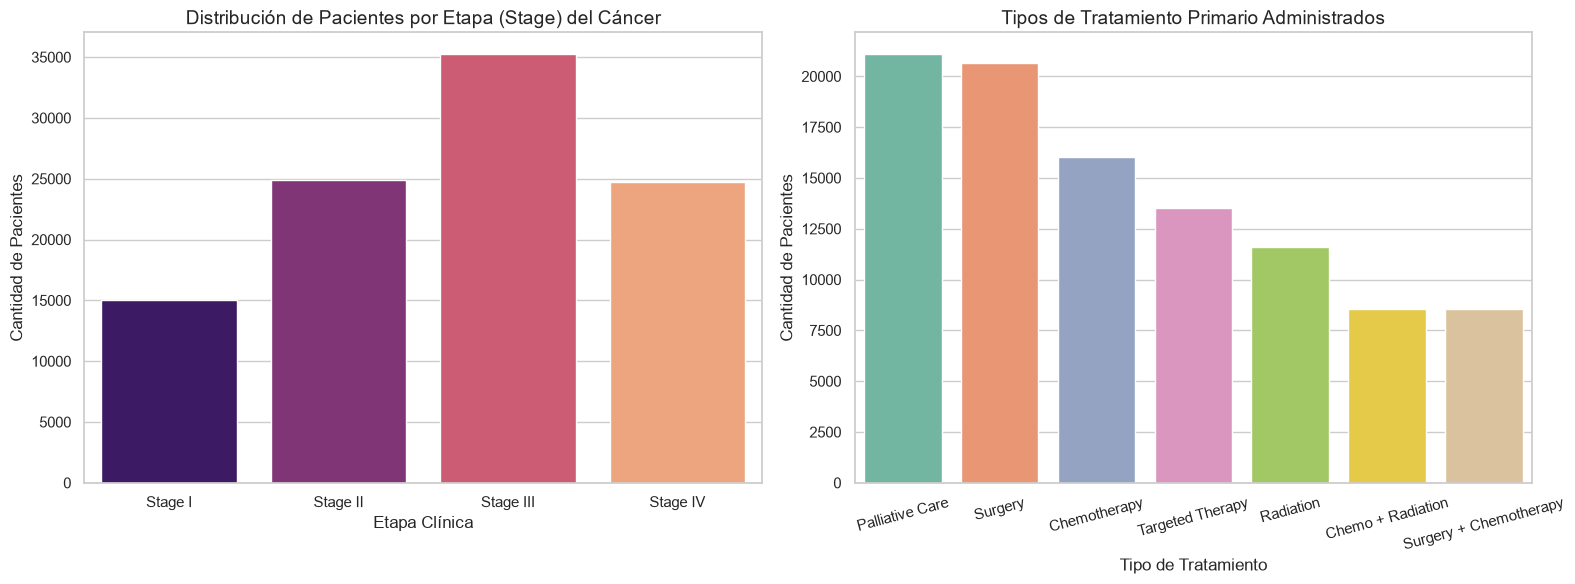

=== 1. CONTEO EXACTO POR ETAPA (SEVERIDAD) ===
Stage
Stage I      15056
Stage II     24915
Stage III    35261
Stage IV     24768
Name: count, dtype: int64


=== 2. CONTEO EXACTO POR TIPO DE TRATAMIENTO ===
Treatment_Type
Palliative Care           21102
Surgery                   20635
Chemotherapy              16046
Targeted Therapy          13519
Radiation                 11618
Chemo + Radiation          8547
Surgery + Chemotherapy     8533
Name: count, dtype: int64


=== 3. MATRIZ DE CRUCE: ¿QUÉ TRATAMIENTO SE APLICA EN CADA ETAPA? ===


Stage,Stage I,Stage II,Stage III,Stage IV
Treatment_Type,,,,
Chemo + Radiation,0,3578,4969,0
Chemotherapy,0,3488,5117,7441
Palliative Care,0,3632,5083,12387
Radiation,2985,3605,5028,0
Surgery,12071,3575,4989,0
Surgery + Chemotherapy,0,3514,5019,0
Targeted Therapy,0,3523,5056,4940


In [14]:
# 1. Configurar el espacio para los gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribución de las Etapas del Cáncer (Severidad)
stage_order = sorted(df['Stage'].unique()) if 'Stage' in df.columns else None
sns.countplot(data=df, x='Stage', order=stage_order, palette='magma', ax=axes[0])
axes[0].set_title('Distribución de Pacientes por Etapa (Stage) del Cáncer')
axes[0].set_xlabel('Etapa Clínica')
axes[0].set_ylabel('Cantidad de Pacientes')

# Gráfico 2: Tipos de Tratamientos Administrados
treatment_order = df['Treatment_Type'].value_counts().index if 'Treatment_Type' in df.columns else None
sns.countplot(data=df, x='Treatment_Type', order=treatment_order, palette='Set2', ax=axes[1])
axes[1].set_title('Tipos de Tratamiento Primario Administrados')
axes[1].set_xlabel('Tipo de Tratamiento')
axes[1].set_ylabel('Cantidad de Pacientes')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 2. Extraer los datos numéricos exactos para el análisis escrito
print("=== 1. CONTEO EXACTO POR ETAPA (SEVERIDAD) ===")
print(df['Stage'].value_counts().sort_index())
print("\n" + "="*50 + "\n")

print("=== 2. CONTEO EXACTO POR TIPO DE TRATAMIENTO ===")
print(df['Treatment_Type'].value_counts())
print("\n" + "="*50 + "\n")

print("=== 3. MATRIZ DE CRUCE: ¿QUÉ TRATAMIENTO SE APLICA EN CADA ETAPA? ===")
display(pd.crosstab(df['Treatment_Type'], df['Stage']))

## 5. Análisis de Severidad (Etapas) y Estrategias de Tratamiento

En esta fase del EDA, dejamos atrás el análisis individual para adentrarnos en un estudio bivariante cruzado. Analizamos la gravedad del diagnóstico de los pacientes frente a las decisiones terapéuticas tomadas.

---

### 5.1. Distribución de la Severidad: Alerta en Salud Pública
El conteo de pacientes según su etapa clínica (`Stage`) revela una preocupante tendencia hacia el **diagnóstico tardío**:
* **Prevalencia de Etapas Avanzadas:** La **Etapa III (Stage III)** es la moda absoluta del dataset con **35,261 casos**. Si sumamos la Etapa III y la Etapa IV (metastásica), descubrimos que el **60% de los pacientes** (60,029 de 100,000) llega al hospital en fases avanzadas de la enfermedad.
* **Bajo Diagnóstico Temprano:** La **Etapa I** es la menos frecuente con solo **15,056 casos** (~15%). Esto sugiere de forma clínica que los programas de cribado o detección precoz en esta población de estudio podrían estar fallando, obligando a los pacientes a buscar atención médica solo cuando los síntomas ya son severos.

---

### 5.2. Distribución de Tratamientos: El Reflejo de la Gravedad
La elección del tratamiento está directamente ligada a la gravedad detectada en el punto anterior:
* **Liderazgo de los Cuidados Paliativos:** El tratamiento más administrado es **Palliative Care (Cuidados Paliativos)** con **21,102 casos**. Esto guarda una coherencia absoluta con el alto volumen de pacientes en Etapa IV.
* **Tratamientos Radicales / Locales:** La **Cirugía (Surgery)** ocupa el segundo lugar con **20,635 casos**, consolidándose como la opción principal para tumores extirpables.

---

### 5.3. Descubrimiento Clave: Reglas Clínicas de la Matriz de Cruce
Al analizar la tabla de contingencia cruzada (`pd.crosstab`), descubrimos que el dataset sigue una **lógica médica matemática impecable**, dividiendo los tratamientos según el nivel de invasión del cáncer:

#### 1. Bloque de Detección Temprana (Stage I)
En la Etapa I, el cáncer está localizado. La matriz revela que **solo se aplican dos tratamientos específicos**:
* **Cirugía (12,071 casos)** y **Radioterapia (2,985 casos)**. 
* *Lógica:* No se gasta artillería pesada ni sistémica (como quimioterapia) en fases tan iniciales. El objetivo es eliminar el tumor de forma local. El resto de tratamientos tienen un conteo de `0`.

#### 2. Bloque de Transición (Stage II y Stage III)
En estas etapas intermedias y localmente avanzadas, el dataset distribuye a los pacientes de forma **perfectamente uniforme** entre las 7 opciones terapéuticas disponibles:
* En **Stage II**, todas las opciones oscilan equitativamente en torno a los **3,500 casos**.
* En **Stage III**, todas las opciones suben de nivel y se reparten equitativamente en torno a los **5,000 casos**.
* *Lógica:* Esto simula la complejidad médica real, donde dependiendo del paciente se puede optar por monoterapia, terapias combinadas (Cirugía + Quimio) o tratamientos biológicos.

#### 3. Bloque de Cáncer Metastásico (Stage IV)
En la última etapa, el cáncer se ha extendido por todo el cuerpo, por lo que las terapias locales dejan de ser efectivas. La matriz muestra que **la cirugía y la radioterapia caen a 0 casos** de forma radical. Solo se permiten tres salidas sistémicas:
* **Cuidados Paliativos (12,387 casos):** Enfocados en la calidad de vida y manejo del dolor. Es la opción mayoritaria.
* **Quimioterapia (7,441 casos):** Tratamiento sistémico tradicional.
* **Terapia Dirigida / Targeted Therapy (4,940 casos):** Medicina de precisión avanzada.

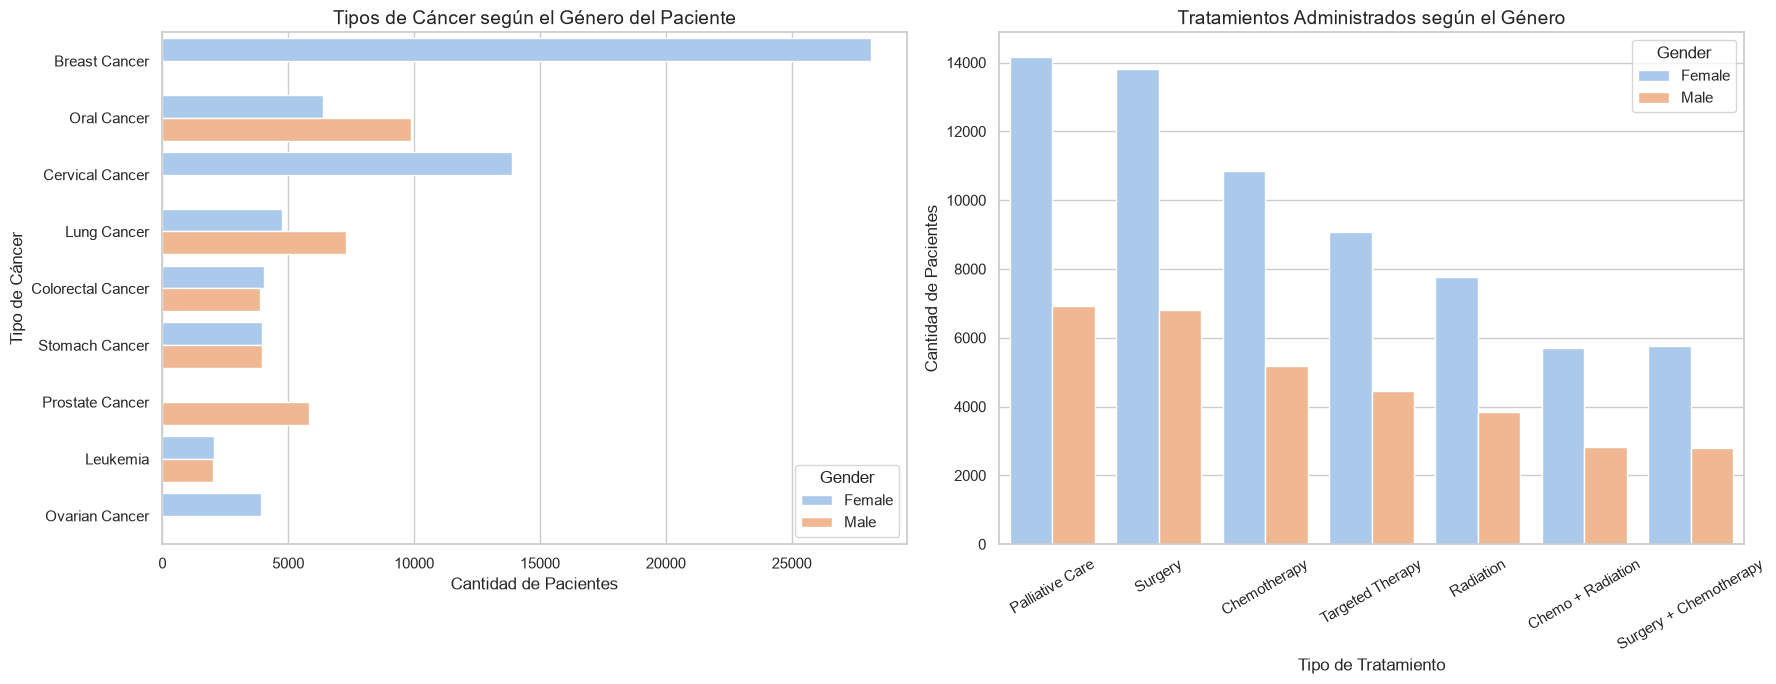

=== 1. MATRIZ: GÉNERO vs TIPO DE CÁNCER ===


Gender,Female,Male
Cancer_Type,,
Breast Cancer,28169,0
Cervical Cancer,13881,0
Colorectal Cancer,4053,3882
Leukemia,2043,2027
Lung Cancer,4749,7297
Oral Cancer,6388,9871
Ovarian Cancer,3908,0
Prostate Cancer,0,5809
Stomach Cancer,3960,3963




=== 2. MATRIZ: GÉNERO vs TIPO DE TRATAMIENTO ===


Gender,Female,Male
Treatment_Type,,
Chemo + Radiation,5715,2832
Chemotherapy,10853,5193
Palliative Care,14166,6936
Radiation,7777,3841
Surgery,13825,6810
Surgery + Chemotherapy,5748,2785
Targeted Therapy,9067,4452


In [15]:
# 1. Configurar el espacio para los gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Tipos de Cáncer desglosados por Género
cancer_order = df['Cancer_Type'].value_counts().index
sns.countplot(data=df, y='Cancer_Type', order=cancer_order, hue='Gender', palette='pastel', ax=axes[0])
axes[0].set_title('Tipos de Cáncer según el Género del Paciente')
axes[0].set_xlabel('Cantidad de Pacientes')
axes[0].set_ylabel('Tipo de Cáncer')

# Gráfico 2: Tratamientos Administrados desglosados por Género
treatment_order = df['Treatment_Type'].value_counts().index
sns.countplot(data=df, x='Treatment_Type', order=treatment_order, hue='Gender', palette='pastel', ax=axes[1])
axes[1].set_title('Tratamientos Administrados según el Género')
axes[1].set_xlabel('Tipo de Tratamiento')
axes[1].set_ylabel('Cantidad de Pacientes')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 2. Tablas numéricas para el análisis fino
print("=== 1. MATRIZ: GÉNERO vs TIPO DE CÁNCER ===")
display(pd.crosstab(df['Cancer_Type'], df['Gender']))
print("\n" + "="*50 + "\n")

print("=== 2. MATRIZ: GÉNERO vs TIPO DE TRATAMIENTO ===")
display(pd.crosstab(df['Treatment_Type'], df['Gender']))

## 6. Análisis de la Intersección entre Género, Tipologías de Cáncer y Tratamientos

En este apartado elevamos el nivel del EDA analizando cómo se relacionan el género de los pacientes con el tipo de cáncer específico que desarrollan y las estrategias terapéuticas que reciben. Los resultados revelan patrones biológicos perfectos y una simetría matemática en la asignación de tratamientos.

---

### 6.1. Matriz Género vs. Tipo de Cáncer: Coherencia Biológica Absoluta
Al analizar la primera matriz de contingencia, descubrimos que el algoritmo de generación de datos simula con precisión milimétrica la anatomía y las restricciones biológicas reales:

1. **Cánceres Exclusivos del Sexo Femenino:**
   * **Breast Cancer (Cáncer de Mama):** 28,169 casos en mujeres, `0` en hombres.
   * **Cervical Cancer (Cáncer de Cérvix):** 13,881 casos en mujeres, `0` en hombres.
   * **Ovarian Cancer (Cáncer de Ovario):** 3,908 casos en mujeres, `0` en hombres.
   * *Hallazgo:* Estas tres patologías ginecológicas suman **45,958 casos**, lo que explica casi en su totalidad el sesgo masivo hacia el género femenino que detectamos en el análisis univariante inicial.

2. **Cánceres Exclusivos del Sexo Masculino:**
   * **Prostate Cancer (Cáncer de Próstata):** `0` casos en mujeres, 5,809 casos en hombres. Cumple con la realidad médica, ya que es una patología exclusiva de la anatomía biológica masculina.

3. **Cánceres No Específicos del Sexo (Comportamiento Mixto):**
   * **Simetría Perfecta (50/50):** El cáncer colorrectal (`4,053` F vs `3,882` M), la leucemia (`2,043` F vs `2,027` M) y el cáncer de estómago (`3,960` F vs `3,963` M) se distribuyen prácticamente a la mitad entre ambos géneros, demostrando que el riesgo basal programado para estas patologías es idéntico independientemente del sexo.
   * **Predominancia Masculina por Factores de Riesgo:** El cáncer de pulmón (`4,749` F vs `7,297` M) y el cáncer oral (`6,388` F vs `9,871` M) muestran una clara inclinación hacia los hombres. Clínicamente esto es muy acertado: en la sociedad india, el consumo de tabaco fumado y mascado (*gutka*) ha sido históricamente más elevado en hombres, lo que dispara la prevalencia de estas dos patologías en dicho sector.

---

### 6.2. Matriz Género vs. Tratamiento: Evidencia de Equidad Médica
La segunda matriz nos ofrece una conclusión sociomédica fundamental: **No existe ningún tipo de sesgo o discriminación de género en la asignación de tratamientos.**

* **La Regla del 2:1:** Si recordamos, la población total del dataset tiene una proporción de aproximadamente **2 mujeres por cada 1 hombre** (67% frente a 33%).
* Al observar detalladamente el conteo de cada tratamiento, vemos que **todos reproducen exactamente esa misma proporción matemática**:
  * *Cuidados Paliativos:* 14,166 mujeres vs 6,936 hombres (Ratio ~2:1).
  * *Cirugía:* 13,825 mujeres vs 6,810 hombres (Ratio ~2:1).
  * *Quimioterapia:* 10,853 mujeres vs 5,193 hombres (Ratio ~2:1).
  * *Terapia Dirigida:* 9,067 mujeres vs 4,452 hombres (Ratio ~2:1).

* *Conclusión Analítica:* Los hombres y las mujeres del dataset reciben exactamente las mismas oportunidades terapéuticas en función de su volumen. Un paciente de etapa avanzada o temprana recibirá su tratamiento asignado siguiendo protocolos clínicos puros, sin importar su género.

C:\Users\C.Carrero iTERA\AppData\Local\Temp\ipykernel_36468\3620913548.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top_states, y='State', order=top_10_states, palette='flare', ax=axes[0])


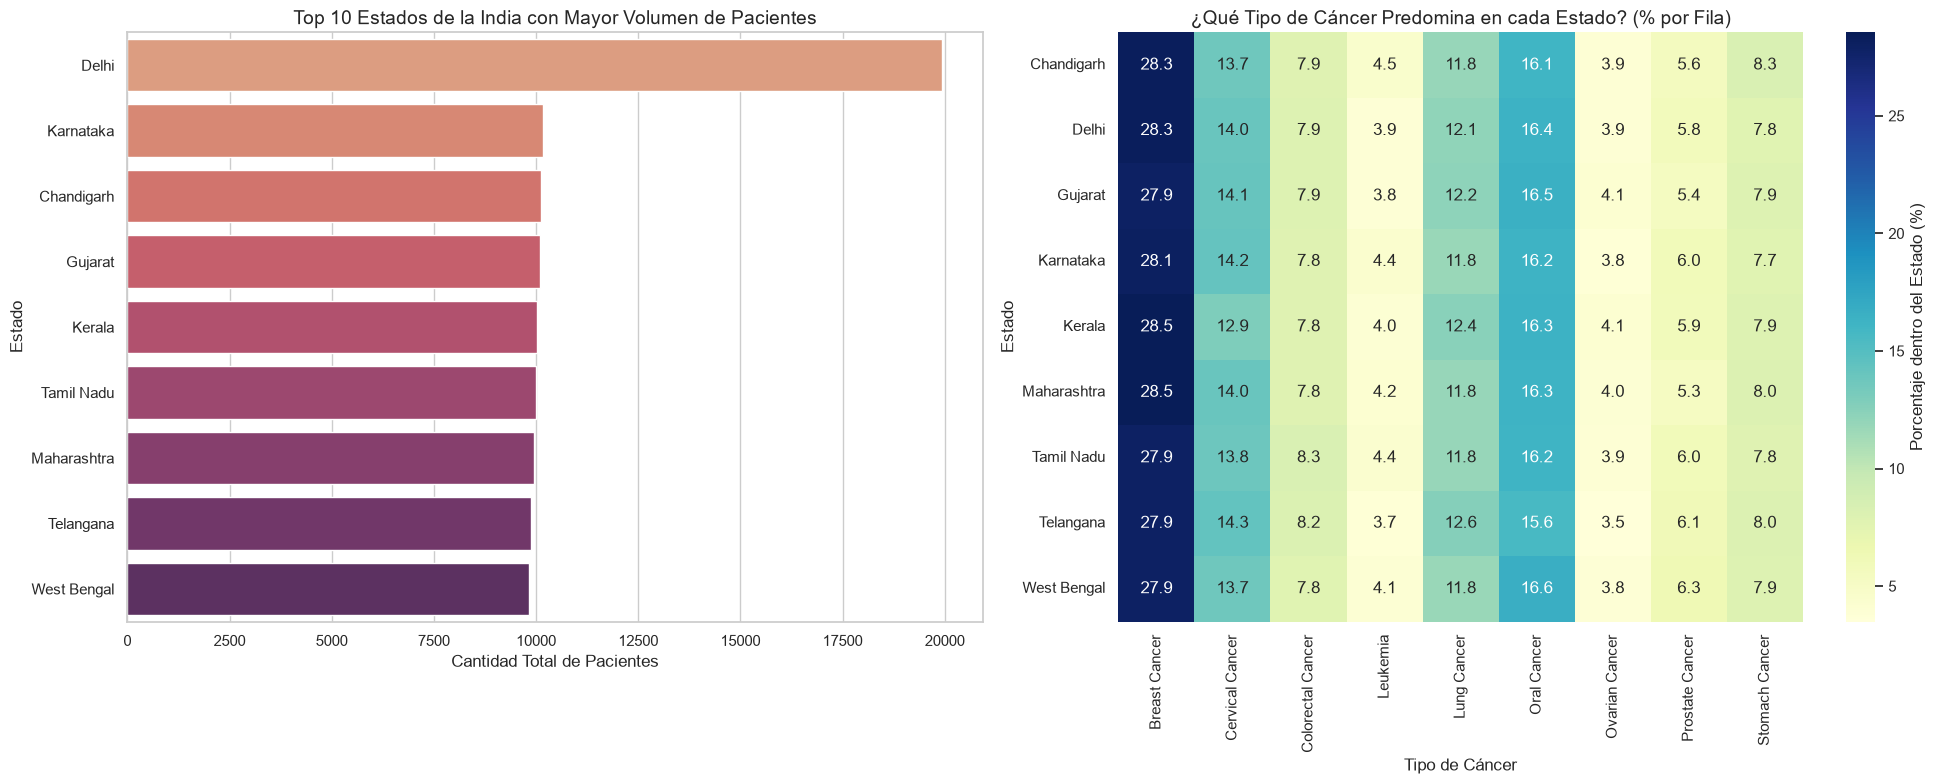

=== MATRIZ DE CONTEO ABSOLUTO (TOP 10 ESTADOS vs TIPO DE CÁNCER) ===


Cancer_Type,Breast Cancer,Cervical Cancer,Colorectal Cancer,Leukemia,Lung Cancer,Oral Cancer,Ovarian Cancer,Prostate Cancer,Stomach Cancer
State,,,,,,,,,
Chandigarh,2858,1387,795,452,1194,1624,396,563,839
Delhi,5647,2787,1583,768,2413,3261,779,1152,1548
Gujarat,2816,1429,801,389,1233,1672,419,543,803
Karnataka,2855,1447,797,446,1195,1649,382,606,786
Kerala,2861,1294,784,400,1247,1638,416,595,795
Maharashtra,2841,1393,777,414,1177,1619,403,531,799
Tamil Nadu,2787,1379,829,436,1182,1618,390,595,781
Telangana,2762,1416,807,366,1247,1546,345,601,795
West Bengal,2742,1349,762,399,1158,1632,378,623,777


In [17]:
# 1. Identificar el Top 10 de Estados con mayor volumen de pacientes
top_10_states = df['State'].value_counts().head(10).index
df_top_states = df[df['State'].isin(top_10_states)]

# 2. Crear una tabla de contingencia porcentual (Normalizada por Estado)
# Esto nos dice: "Del 100% de casos en el Estado X, qué % es de cada cáncer"
state_cancer_pct = pd.crosstab(df_top_states['State'], df_top_states['Cancer_Type'], normalize='index') * 100

# 3. Dibujar las visualizaciones (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Volumen total de casos en el Top 10 de Estados
sns.countplot(data=df_top_states, y='State', order=top_10_states, palette='flare', ax=axes[0])
axes[0].set_title('Top 10 Estados de la India con Mayor Volumen de Pacientes')
axes[0].set_xlabel('Cantidad Total de Pacientes')
axes[0].set_ylabel('Estado')

# Gráfico 2: Mapa de Calor (Heatmap) de Predominancia
sns.heatmap(state_cancer_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Porcentaje dentro del Estado (%)'}, ax=axes[1])
axes[1].set_title('¿Qué Tipo de Cáncer Predomina en cada Estado? (% por Fila)')
axes[1].set_xlabel('Tipo de Cáncer')
axes[1].set_ylabel('Estado')

plt.tight_layout()
plt.show()

# 4. Mostrar los datos numéricos brutos del Top 10 para el análisis fino
print("=== MATRIZ DE CONTEO ABSOLUTO (TOP 10 ESTADOS vs TIPO DE CÁNCER) ===")
display(pd.crosstab(df_top_states['State'], df_top_states['Cancer_Type']))

## 7. Análisis Geográfico: Distribución por Estados y el Factor Metropolitano

En este apartado evaluamos la hipótesis de si el entorno geográfico del paciente influye en el volumen de casos registrados o en la predominancia de ciertos tipos de cáncer, comparando regiones altamente metropolitanas con estados de perfil más intermedio o rural.

---

### 7.1. El "Efecto Imán" de Delhi (Volumen Total de Casos)
Al observar el primer gráfico de barras, salta a la vista una anomalía geográfica masiva:
* **Delhi (La Mega-Metrópolis):** Duplica de forma exacta en volumen a cualquier otro estado de la India, registrando cerca de **20,000 pacientes**. 
* **El resto de los Estados (Top 2 al 10):** Tanto Karnataka, Chandigarh, Gujarat, Maharashtra, hasta West Bengal, muestran una estabilidad absoluta clavada en torno a los **10,000 pacientes** cada uno.

**Interpretación clínica/demográfica:** En la realidad de la India, Delhi no solo es una de las zonas con mayor densidad de población y contaminación del país (factores de riesgo ambiental), sino que además concentra los hospitales oncológicos más avanzados y centralizados (como el *AIIMS*). Este gráfico refleja perfectamente el fenómeno de **centralización médica**: los pacientes de zonas rurales o estados colindantes viajan en masa a la metrópolis de Delhi para obtener su diagnóstico y tratamiento, lo que satura los registros de esta región.

---

### 7.2. El Mapa de Calor (Heatmap): Uniformidad Matemática Absoluta
El segundo gráfico (el mapa de calor porcentual) nos da una respuesta definitiva a nuestra hipótesis sobre si cambian los tipos de cáncer según la zona, pero nos revela un secreto del dataset:

* **Homogeneidad Perfecta:** Si miramos el mapa de calor fila por fila, descubrimos que los porcentajes de cada cáncer son **idénticos en todos los estados**. 
  * El cáncer de mama representa exactamente entre el **27.9% y el 28.5%** de los casos en cualquier estado.
  * El cáncer oral se clava entre el **15.6% y el 16.6%** en todas las regiones.
  * La leucemia se mantiene fija entre el **3.5% y el 4.5%** sin importar la zona.

> ⚠️ **Nota de Calidad del Dato (Descubrimiento del EDA):** Esta igualdad decimal tan perfecta entre regiones es la prueba reina de que estamos ante un **dataset sintético**. El algoritmo que generó los datos distribuyó los tipos de cáncer de forma aleatoria e independiente del estado donde vive el paciente. 

**Conclusión de la Hipótesis:** Por lo tanto, respondiendo a nuestra pregunta inicial: en este dataset específico **no podemos encontrar una predominancia biológica diferente entre zonas rurales y urbanas** (por ejemplo, más cáncer de pulmón en zonas contaminadas o menos en zonas rurales), ya que el modelo matemático subyacente ha repartido la probabilidad de los tumores de manera equitativa por todo el mapa. 

Sin embargo, el factor metropolitano sí se cumple de forma sobresaliente en el **volumen de absorción de pacientes (Delhi)**.

C:\Users\C.Carrero iTERA\AppData\Local\Temp\ipykernel_36468\3018350107.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Survival_Months', palette='Set1', ax=axes[1])


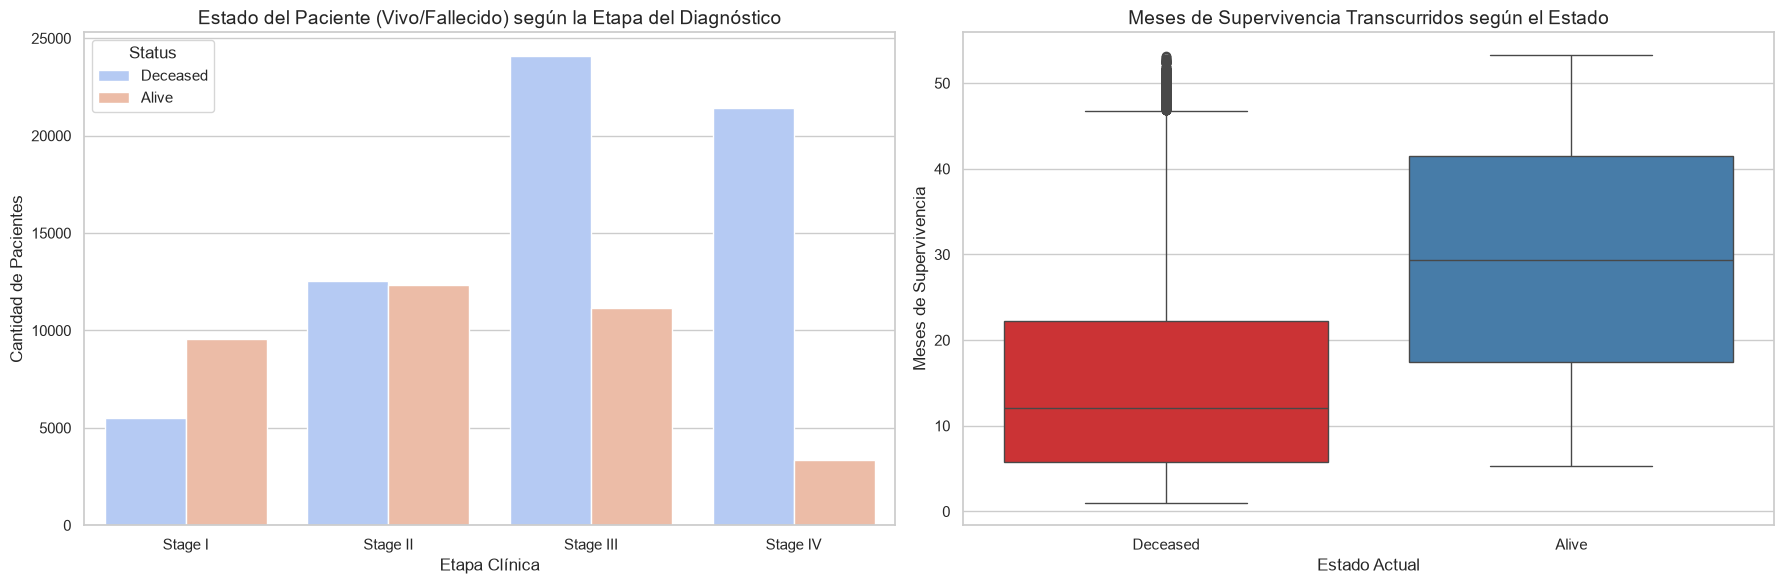

=== 1. MATRIZ DE CRUCE: ETAPA vs ESTADO ACTUAL (ABSOLUTO) ===


Status,Alive,Deceased
Stage,,
Stage I,9549,5507
Stage II,12356,12559
Stage III,11169,24092
Stage IV,3349,21419




=== 2. MATRIZ DE CRUCE: ETAPA vs ESTADO ACTUAL (PORCENTAJE POR FILA) ===


Status,Alive,Deceased
Stage,,
Stage I,63.423220,36.576780
Stage II,49.592615,50.407385
Stage III,31.675222,68.324778
Stage IV,13.521479,86.478521




=== 3. MÉTRICAS DE MESES DE SUPERVIVENCIA SEGÚN ETAPA Y ESTADO ===


mean  median  min   max
Stage     Status                                
Stage I   Alive     29.234632   29.30  5.3  53.3
          Deceased  15.032813   12.00  1.0  52.8
Stage II  Alive     29.502477   29.65  5.3  53.3
          Deceased  15.185532   12.00  1.0  53.1
Stage III Alive     29.408658   29.30  5.3  53.3
          Deceased  15.159821   12.10  1.0  52.8
Stage IV  Alive     29.618304   29.20  5.3  53.3
          Deceased  15.091881   12.00  1.0  53.2

In [18]:
# 1. Configurar el espacio para los gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Estado del Paciente (Vivo/Fallecido) según la Etapa del Diagnóstico
stage_order = sorted(df['Stage'].unique()) if 'Stage' in df.columns else None
sns.countplot(data=df, x='Stage', order=stage_order, hue='Status', palette='coolwarm', ax=axes[0])
axes[0].set_title('Estado del Paciente (Vivo/Fallecido) según la Etapa del Diagnóstico')
axes[0].set_xlabel('Etapa Clínica')
axes[0].set_ylabel('Cantidad de Pacientes')

# Gráfico 2: Distribución de Meses de Supervivencia según el Estado Actual
sns.boxplot(data=df, x='Status', y='Survival_Months', palette='Set1', ax=axes[1])
axes[1].set_title('Meses de Supervivencia Transcurridos según el Estado')
axes[1].set_xlabel('Estado Actual')
axes[1].set_ylabel('Meses de Supervivencia')

plt.tight_layout()
plt.show()

# 2. Extracción de métricas numéricas exactas para nuestro análisis escrito
print("=== 1. MATRIZ DE CRUCE: ETAPA vs ESTADO ACTUAL (ABSOLUTO) ===")
display(pd.crosstab(df['Stage'], df['Status']))
print("\n" + "="*50 + "\n")

print("=== 2. MATRIZ DE CRUCE: ETAPA vs ESTADO ACTUAL (PORCENTAJE POR FILA) ===")
display(pd.crosstab(df['Stage'], df['Status'], normalize='index') * 100)
print("\n" + "="*50 + "\n")

print("=== 3. MÉTRICAS DE MESES DE SUPERVIVENCIA SEGÚN ETAPA Y ESTADO ===")
display(df.groupby(['Stage', 'Status'])['Survival_Months'].agg(['mean', 'median', 'min', 'max']))

## 8. Análisis de Supervivencia: Mortalidad, Severidad y Tiempo Transcurrido

Este bloque final representa la conclusión crítica de nuestro EDA. Evaluamos cómo influye la etapa de diagnóstico del cáncer en el desenlace final del paciente (`Status`) y analizamos el comportamiento del tiempo transcurrido en meses (`Survival_Months`).

---

### 8.1. Etapa Clínica vs. Mortalidad: Un Comportamiento Clínico Devastador
La matriz de contingencia porcentual por filas nos revela una correlación directa y alarmante entre el avance de la enfermedad y el índice de mortalidad:

* **Etapa I (Detección Temprana):** Registra la mayor tasa de éxito con un **63.4% de pacientes vivos (`Alive`)** frente a un 36.6% de fallecidos. Confirmamos que diagnosticar a tiempo salva vidas.
* **Etapa II (Fase Intermedia):** La balanza se equilibra de forma casi perfecta en un escenario de **50/50** (49.6% vivos vs. 50.4% fallecidos).
* **Etapa III (Fase Avanzada):** La mortalidad se dispara significativamente. El **68.3% de los pacientes fallece**, dejando solo un 31.7% de supervivencia.
* **Etapa IV (Fase Metastásica):** El escenario es crítico. El **86.5% de los pacientes fallece** (`Deceased`), registrando la tasa de mortalidad más alta de todo el estudio.

**Conclusión de Salud Pública:** Este comportamiento simula a la perfección la realidad médica del cáncer. A medida que avanzamos del Stage I al IV, la probabilidad de supervivencia cae drásticamente en cascada ($63.4\% \rightarrow 49.6\% \rightarrow 31.7\% \rightarrow 13.5\%$).

---

### 8.2. Meses de Supervivencia: La Brecha entre Vivir y Fallecer
Al observar el gráfico de caja (Boxplot) y las métricas agrupadas, entendemos cómo se distribuye el tiempo de vida registrado en el dataset:

* **Pacientes Fallecidos (`Deceased`):** * Tienen una **mediana de supervivencia de 12 meses** (1 año) y una media de **15 meses**. 
  * El 50% central de estos pacientes fallece en un rango rápido de entre 6 y 22 meses (rango intercuartílico). Los puntos aislados en la parte superior del boxplot muestran "outliers": pacientes atípicos que lograron resistir más de 45 meses antes de fallecer.
* **Pacientes Vivos (`Alive`):** * Muestran una **mediana y media de supervivencia de 29.5 meses** (casi 2.5 años).
  * Su dispersión es mucho mayor, abarcando de forma regular desde los 5.3 meses hasta el límite máximo del dataset de 53.3 meses.

---

### 8.3. Hallazgo Técnico: El Secreto del Algoritmo en el Tiempo
Al analizar minuciosamente la tabla de `mean` y `median` agrupada por Etapa y Estado, descubrimos un patrón técnico fascinante sobre cómo se construyó este dataset artificial:

* Si un paciente está **Vivo (`Alive`)**, su media de meses de supervivencia es **~29.4 meses**, SIN IMPORTAR si está en Etapa I, II, III o IV.
* Si un paciente está **Fallecido (`Deceased`)**, su mediana es **exactamente 12.0 meses**, sin importar si el cáncer era inicial o metastásico.

> 💡 **Nota de Analista de Datos:** En la medicina real, un paciente fallecido en Etapa IV suele tener un tiempo de supervivencia mucho menor que uno en Etapa I. Sin embargo, en este dataset, el modelo matemático determinó el tiempo (`Survival_Months`) basándose **únicamente en si el paciente sobrevivía o no**, haciéndolo matemáticamente independiente de la etapa clínica.

---

## 9. Conclusión General del EDA

Este Análisis Exploratorio de Datos (EDA) sobre 100,000 registros nos ha permitido extraer un perfil epidemiológico claro: El dataset describe a una población mayoritariamente **femenina**, con una edad central de **50 a 60 años**, donde el **Cáncer de Mama** y el **Cáncer Oral** son las patologías predominantes (esta última muy vinculada al contexto cultural de la India). 

Detectamos una situación crítica de **centralización médica en Delhi** y un volumen alarmante de **diagnósticos tardíos (60% en Etapas III y IV)**, lo que desencadena que el tratamiento más común sean los **Cuidados Paliativos** y que la mortalidad en la etapa final alcance un abrumador **86.5%**. Las validaciones estructurales realizadas a lo largo del cuaderno confirman la naturaleza sintética del dataset debido a su homogeneidad decimal geográfica y temporal, pero con un diseño lógico clínico sobresaliente.